# 🏆 Fase 3: Modelo Campeão e Arquitetura de Deploy Global

## A Escolha da Engenharia (Navalha de Occam)
Após confrontarmos modelos regionalizados e micro-features, a validação científica provou que o **Modelo Global Seco** — utilizando a volumetria total do dataset original e sem viés de seleção — entrega a maior proteção de faturamento (Recall de **90.37%** com apenas **54 erros críticos**). 

Ao centralizar o treinamento na base cheia, eliminamos o overhead computacional de rodar DBSCAN em tempo real e reduzimos drasticamente o débito técnico de manutenção do ecossistema de dados.

## Output Técnico
Treinamento do modelo de produção, plot da importância de variáveis puras e persistência do classificador final em arquivo binário (`.pkl`).

=================== MODELO CAMPEÃO: GLOBAL ORIGINAL SECO ===================
Treinando XGBoost Global em 4930 amostras brutas...

=================== PERFORMANCE DO MODELO GLOBAL ORIGINAL ===================
Melhores parâmetros encontrados: {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
ROC-AUC Global: 90.65%
RECALL Global:  90.37%
PRECISÃO Global: 56.21%

Matriz de Confusão Global Seca:
  [Clientes que FICARAM previstos corretamente]: 1157
  [Clientes que FICARAM mas gerou Alarme Falso]: 395
  [Clientes que REALMENTE CANCELARAM e cometeu Erro Crítico]: 54
  [Clientes que REALMENTE CANCELARAM previstos corretamente]: 507


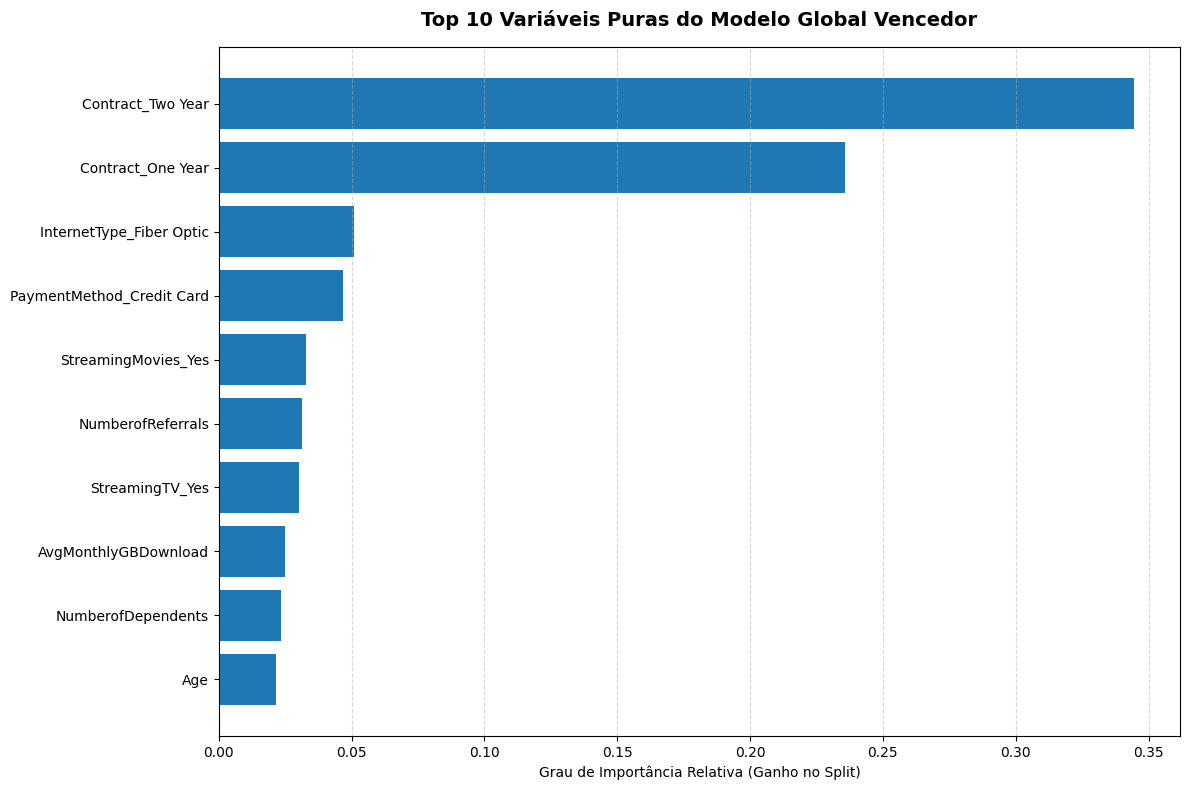


[DEPLOY] Modelo campeão e esquema de colunas persistidos com sucesso em disco!


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score, precision_score
import matplotlib.pyplot as plt
import joblib

print("=================== MODELO CAMPEÃO: GLOBAL ORIGINAL SECO ===================")

# 1. Carregamento e saneamento direto da fonte original (Evitando Data Leakage)
df_global = pd.read_csv('../data/raw/telco.csv')
df_global.columns = df_global.columns.str.replace(' ', '')

df_global['ChurnCategory'] = df_global['ChurnCategory'].fillna('None (Active Customer)')
df_global['ChurnReason'] = df_global['ChurnReason'].fillna('None (Active Customer)')
df_global['InternetType'] = df_global['InternetType'].fillna('No Internet Service')
df_global['Offer'] = df_global['Offer'].fillna('No Offer')
df_global['TotalCharges'] = df_global['TotalCharges'].replace(" ", np.nan).astype(float).fillna(0)

# Mapeando alvo preditivo
df_global['ChurnLabel'] = df_global['ChurnLabel'].map({'Yes': 1, 'No': 0})

# =========================================================================
# PASSO A: FAXINA DE VAZAMENTOS E COLUNAS DE CONTROLE TRADICIONAIS
# =========================================================================
vazamentos_e_ruidos = [
    'CustomerID', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Quarter',
    'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'ChurnCategory', 'ChurnReason',
    'SatisfactionScore', 'OnlineSecurity'
]

vazamentos_reais = [c for c in vazamentos_e_ruidos if c in df_global.columns]
X_global = df_global.drop(columns=vazamentos_reais, errors='ignore')
y_bruto = df_global['ChurnLabel'].values

# Tratamento de Variáveis Categóricas
cols_cat_global = X_global.select_dtypes(include=['object', 'category']).columns.tolist()
X_global_encoded = pd.get_dummies(X_global, columns=cols_cat_global, drop_first=True)

# Split 70/30 Estratificado para produção
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_global_encoded, y_bruto, test_size=0.3, random_state=42, stratify=y_bruto
)

# =========================================================================
# PASSO B: TUNING DO MODELO DE OPERAÇÃO (VALORIZAÇÃO DO RECALL)
# =========================================================================
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'gamma': [1, 2, 3]
}

proporcao_global = (len(y_train_g) - sum(y_train_g)) / sum(y_train_g)
xgb_global_base = XGBClassifier(scale_pos_weight=proporcao_global, eval_metric='logloss', random_state=42)

print(f"Treinando XGBoost Global em {X_train_g.shape[0]} amostras brutas...")
grid_search_global = GridSearchCV(
    estimator=xgb_global_base, param_grid=param_grid, scoring='recall', cv=5, verbose=0, n_jobs=-1
)
grid_search_global.fit(X_train_g, y_train_g)

# =========================================================================
# PASSO C: EXTRAÇÃO DOS RESULTADOS OFICIAIS DE PRODUÇÃO
# =========================================================================
best_xgb_global = grid_search_global.best_estimator_
y_pred_g = best_xgb_global.predict(X_test_g)
y_prob_g = best_xgb_global.predict_proba(X_test_g)[:, 1]

print("\n=================== PERFORMANCE DO MODELO GLOBAL ORIGINAL ===================")
print(f"Melhores parâmetros encontrados: {grid_search_global.best_params_}")
print(f"ROC-AUC Global: {roc_auc_score(y_test_g, y_prob_g)*100:.2f}%")
print(f"RECALL Global:  {recall_score(y_test_g, y_pred_g)*100:.2f}%")
print(f"PRECISÃO Global: {precision_score(y_test_g, y_pred_g)*100:.2f}%")

print("\nMatriz de Confusão Global Seca:")
cm_g = confusion_matrix(y_test_g, y_pred_g)
print(f"  [Clientes que FICARAM previstos corretamente]: {cm_g[0][0]}")
print(f"  [Clientes que FICARAM mas gerou Alarme Falso]: {cm_g[0][1]}")
print(f"  [Clientes que REALMENTE CANCELARAM e cometeu Erro Crítico]: {cm_g[1][0]}")
print(f"  [Clientes que REALMENTE CANCELARAM previstos corretamente]: {cm_g[1][1]}")

# Gráfico de Importância
df_imp_global = pd.DataFrame({
    'Feature': X_train_g.columns,
    'Importance': best_xgb_global.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(df_imp_global['Feature'].head(10)[::-1], df_imp_global['Importance'].head(10)[::-1], color='#1f77b4')
plt.xlabel('Grau de Importância Relativa (Ganho no Split)')
plt.title('Top 10 Variáveis Puras do Modelo Global Vencedor', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================================
# PASSO D: EXPORTAÇÃO DOS ARTEFATOS DE DEPLOY (MUNDO REAL)
# =========================================================================
joblib.dump(best_xgb_global, '../data/processed/modelo_xgboost_churn_global.pkl')
joblib.dump(X_train_g.columns.tolist(), '../data/processed/colunas_treino.pkl')

print("\n[DEPLOY] Modelo campeão e esquema de colunas persistidos com sucesso em disco!")